
# **Predicting Healthcare Expenditures**

## Overview

### Project Goal
*This project builds a machine learning model to predict annual healthcare expenditures using the Medical Expenditure Panel Survey (MEPS). The goal is risk stratification and understanding key drivers in healthcare spending. This includes demographic, insurance, and health status features.*

### Dataset
*Medical Expenditure Panel Survey 2022*: https://meps.ahrq.gov/mepsweb/data_stats/download_data_files_detail.jsp?cboPufNumber=HC-243

## Data Dictionary


### TOTEXP22
**Name**: Total Annual Health Care Expenditures (2022)

**Type**: Numeric (continuous)

**Description**: Total medical spending for the individual across all healthcare services (Including both out-of-pocket and insurer payments) 

**Modeling Note**: Highly right skewed, log-transformed for modeling.


### AGE22X
**Name**: Age (2022)

**Type**: Numeric (integer)

**Description**: Age of the respondent as of the end of the survey year.

### EDUCYR
**Name**: Years of Education

**Type**: Numeric (integer)

**Description**: Total years of completed education.

### SEX
**Name**: Sex

**Type**: Categorical

**Description**: Binary indicator of respondent's sex. Treated as a categorical variable and one-hot encoded.

### RACEV2X
**Name**: Race / Ethnicity

**Type**: Categorical

**Description**: Self-reported race/ethnicity category derived from MEPS survey coding. Encoded categorically for modeling.

### REGION22
**Name**: Census Region (2022)

**Type**: Categorical

**Description**: Geographic region of residence within the US.

### POVCAT22
**Name**: Poverty Status Category (2022)

**Type**: Categorical 

**Description**: Household income category based on federal poverty thresholds.

### MARRY22X
**Name**: Marital Status (2022)

**Type**: Categorical

**Description**: Respondent’s marital status as of survey year.

### INSURC22

**Name**: Insurance Coverage Indicator (2022)

**Type**: Categorical

**Description**: Primary health insurance coverage type (private, public-only, or uninsured)



##### ***All variable definitions and coding conventions are based on the official MEPS Full-Year Consolidated file documentation***


## Data Loading and Initial Inspection

This section loads the MEPS File and performs basic inspection to confirm data structure, varible availability and record counts before analysis

In [1]:
import pyreadstat
import pandas as pd

fp = "h243.sas7bdat"

df, meta = pyreadstat.read_sas7bdat(fp)

print("Rows: ", df.shape[0])
print("Columns: ", df.shape[1])
df.head()

Rows:  22431
Columns:  1420


,DUID,PID,DUPERSID,PANEL,DATAYEAR,FAMID31,FAMID42,FAMID53,FAMID22,FAMIDYR,...,RXOSR22,RXPTR22,RXOTH22,PERWT22F,FAMWT22F,FAMWT22C,SAQWT22F,DIABW22F,VARSTR,VARPSU
0,2460002.0,101.0,2460002101,24.0,2022.0,A,A,A,A,A,...,0.0,0.0,0.0,5728.309495,5232.211986,5232.211986,3994.687140,6034.636755,2082.0,1.0
1,2460006.0,101.0,2460006101,24.0,2022.0,A,A,A,A,A,...,0.0,0.0,0.0,15648.881461,16017.881691,16017.881691,0.000000,0.000000,2001.0,4.0
2,2460006.0,102.0,2460006102,24.0,2022.0,A,A,A,A,A,...,0.0,0.0,0.0,14123.720178,16017.881691,12580.731740,0.000000,0.000000,2001.0,4.0
3,2460010.0,101.0,2460010101,24.0,2022.0,A,A,A,A,A,...,0.0,5288.0,299.0,16982.054917,21905.758877,21905.758877,0.000000,0.000000,2038.0,3.0
4,2460018.0,101.0,2460018101,24.0,2022.0,A,A,A,A,A,...,0.0,10.0,0.0,10682.619947,11344.291012,11344.291012,17152.439412,0.000000,2041.0,1.0


## Variable Selection

To focus analysis on a subset of relevent demographic and socioeconomic variables, a predefined list of columns were selected from the full dataset. An initial check was completed to confirm that all variables were present prior to subsetting

In [2]:
vars = [
    "TOTEXP22",
    "AGE22X",
    "SEX",
    "RACEV2X",
    "REGION22",
    "EDUCYR",
    "POVCAT22",
    "MARRY22X",
    "INSURC22",
    "PERWT22F"
    ]

for col in vars:
    if col in df.columns:
        print(col, "FOUND")
    else:
        print(col, "NOT FOUND")

TOTEXP22 FOUND
AGE22X FOUND
SEX FOUND
RACEV2X FOUND
REGION22 FOUND
EDUCYR FOUND
POVCAT22 FOUND
MARRY22X FOUND
INSURC22 FOUND
PERWT22F FOUND


After confirming variable availability, the dataset was subset to include only selected variables required for analysis

In [3]:
selected_vars = df[[
    "TOTEXP22",
    "AGE22X",
    "SEX",
    "RACEV2X",
    "REGION22",
    "EDUCYR",
    "POVCAT22",
    "MARRY22X",
    "INSURC22",
]].copy()

## Data Review

**TOTEXP22 Distribution (Target Variable)**

Total annual healthcare expenditures are highly right skewed witha. small proportion of individuals accounting for the extremely high costs. 

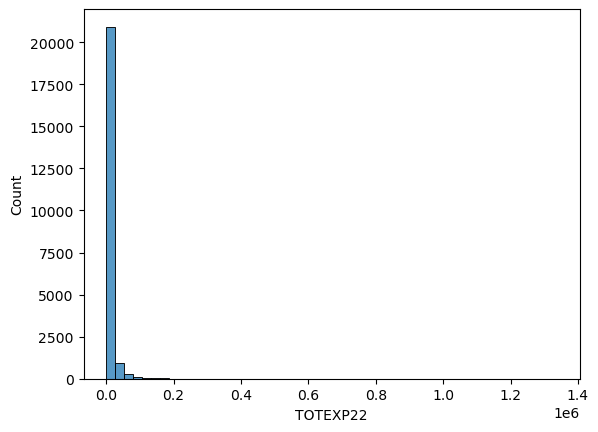

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.histplot(selected_vars["TOTEXP22"], bins= 50)
plt.show()

Apply log transform to normalize the distriution

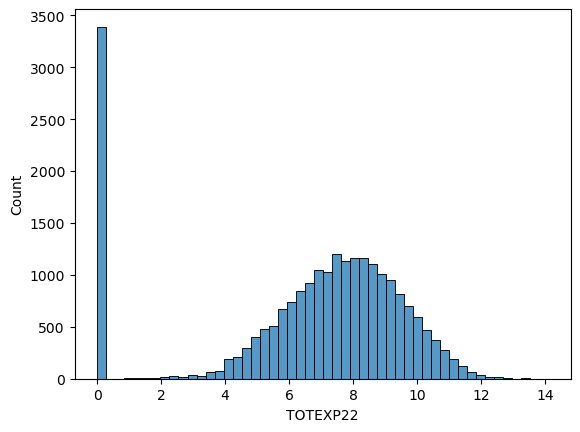

In [5]:
sns.histplot(np.log1p(selected_vars["TOTEXP22"]), bins=50)
plt.show()

Applying log transform to the data reduces skewness, producing a distribution more suitable for regression based models. The 0 represents people who have not spent on healthcare for the year.

**Summary Statistics**

Shows negatives for several variables, in MEPS data these values represent codes for non-response.

In [6]:
selected_vars.describe()

,TOTEXP22,AGE22X,SEX,RACEV2X,REGION22,EDUCYR,POVCAT22,MARRY22X,INSURC22
count,2.243100e+04,22431.000000,22431.000000,22431.000000,22431.000000,22431.000000,22431.000000,22431.000000,22431.000000
mean,7.639477e+03,42.963756,1.527083,1.945254,2.711515,11.114841,3.638982,3.168873,2.276225
std,2.299367e+04,23.998943,0.499277,2.542030,1.060292,5.552522,1.435001,2.029325,1.613426
min,0.000000e+00,-1.000000,1.000000,1.000000,-1.000000,-8.000000,1.000000,-8.000000,1.000000
25%,2.600000e+02,22.000000,1.000000,1.000000,2.000000,9.000000,3.000000,1.000000,1.000000
50%,1.605000e+03,44.000000,2.000000,1.000000,3.000000,12.000000,4.000000,3.000000,2.000000
75%,6.409000e+03,63.000000,2.000000,2.000000,4.000000,16.000000,5.000000,5.000000,3.000000
max,1.338276e+06,85.000000,2.000000,12.000000,4.000000,17.000000,5.000000,6.000000,8.000000


**Feature Type Assesment**

Several variables are stored as integers but many of those represent categories within the variables. This includes sex, race, insurance, marital status and region, while age and years of education are kept as numerical inputs.

*Based on these observations, preprocessing steps were implemented to address skewness, handle MEPS specific missing value codes and prepare numeric and categorical features for modeling*

## Pre-Processing

In [7]:
data = selected_vars

**Remove negative values**

Several variables contain negative values that represents missing or inapplicable responses. These values are replaced with NaN to treat them as missing.

In [8]:
col_with_neg = ["AGE22X", "REGION22", "EDUCYR", "MARRY22X"]

for col in col_with_neg:
    data[col] = data[col].mask((data[col]<0), np.nan)

Given the limited rate of missingness and large sample size, observations with missing predictor values were removed to simplify preprocessing and avoid imputation bias.

In [9]:
data = data.dropna()

**Log transform target variable**

Used log1p to handle value of 0.

In [33]:
data = data.copy()
data["log_totexp"] = np.log1p(data["TOTEXP22"])

**Identify and prep categorical features for encoding**

Predictor variables were seperated into numeric and categorical feature sets.

In [11]:
categ_cols = ["SEX", "RACEV2X", "REGION22", "POVCAT22", "MARRY22X", "INSURC22"]

numer_cols = ["AGE22X", "EDUCYR"]

**Encode categorical variables using One-Hot Encoding**

Dropped first category to prevent multicollinearity.

In [12]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(
    drop= "first",
    sparse_output=False
)

encoded_cat = encoder.fit_transform(data[categ_cols])

encoded_cat_cols = encoder.get_feature_names_out(categ_cols)

encoded_cat_df = pd.DataFrame(
    encoded_cat,
    columns=encoded_cat_cols,
    index=data.index
)

Combined encoded categorical and numeric variables.

In [13]:
X = pd.concat(
    [
        data[numer_cols],
        encoded_cat_df
    ],
    axis = 1
)

**Scale numeric features to give equal weight to each feature**

Numeric features were standardized to have zero mean and unit variance. Prevents variables with larger ranges from dominating the model learnign process.

In [14]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X[numer_cols] = scaler.fit_transform(X[numer_cols])

## Model Training

*Models were trained to predict log transformed annual healthcare expenditures.*

**Train / Test Split**

In [15]:
from sklearn.model_selection import train_test_split

y = data["log_totexp"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Established a naive baseline using a constant predictor to assign the mean expenditure to all test observations. Establishing a minimum performance threshold. 

In [16]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

baseline_pred = np.full(shape=len(y_test), fill_value=y_train.mean())

baseline_r2 = r2_score(y_test, baseline_pred)
baseline_rmse = np.sqrt(mean_squared_error(y_test, baseline_pred))
baseline_mae = mean_absolute_error(y_test, baseline_pred)

print("R-squared: ", baseline_r2)
print("RMSE: ", baseline_rmse)
print("MAE: ", baseline_mae)

R-squared:  -0.00017375332468305693
RMSE:  3.219354135739051
MAE:  2.4563883558942052


### **Linear Models**

#### **Linear Regression Model**

Linear regression model was trained as an initial benchmark to assess the amount variance in healthcare expenditures could be explained by the available features.

In [17]:
from sklearn.linear_model import LinearRegression

linreg = LinearRegression()

linreg.fit(X_train, y_train)


y_pred = linreg.predict(X_test)

r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)

print("R-squared: ", r2)
print("RMSE: ", rmse)
print("MAE: ", mae)

R-squared:  0.26456672186644614
RMSE:  2.7605947942170688
MAE:  2.0689932953117176


Linear regression model shows a 26.5% varience, indicating demographic features do provide a predictive signal. The remaining variance suggested that healthcare is influence by nonlinear relationships.

#### **Ridge Regression**

Ridge regression was trained as a regularized extension of linear regression. Penalized large coefficient values and helps stabilize correlated predictors.

In [18]:
from sklearn.linear_model import Ridge

ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)

y_pred_ridge = ridge.predict(X_test)

ridge_r2 = r2_score(y_test, y_pred_ridge)
ridge_rmse = np.sqrt(mean_squared_error(y_test, y_pred_ridge))
ridge_mae = mean_absolute_error(y_test, y_pred_ridge)

print("R-squared: ", ridge_r2)
print("RMSE: ", ridge_rmse)
print("MAE: ", ridge_mae)

R-squared:  0.264561325862802
RMSE:  2.760604921683889
MAE:  2.069149509773151


Performed nearly the same, which indicated coefficient instability was not the primary driver of model error. Suggested that main performance limitations stem from the linear modeling assumptions and feature signal rather than overfitting.

### **Non-Linear Models**

#### **Random Forest Regressor** ####

Random Forest Regressor was trained to capture nonlinear relationships among predictors. 

In [19]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

rf_r2 = r2_score(y_test, y_pred_rf)
rf_rmse = np.sqrt(mean_squared_error(y_test, y_pred_rf))
rf_mae = mean_absolute_error(y_test, y_pred_rf)

print("R-squared: ", rf_r2)
print("RMSE: ", rf_rmse)
print("MAE: ", rf_mae)

R-squared:  0.14437738435325786
RMSE:  2.9776397501574623
MAE:  2.2532017282060597


Underperformed compared to linear models, suggested that while noninear relationships may exist, the available features do not provide strong standalone signal. Indicated model performance is more constrained by feature signal than by model flexibility. 

#### **Gradient Boosting Regressor**

Gradient Boosting was trained to capture weak nonlinear relationships by iteratively fitting decision trees to the residuals of previous models.

In [20]:
from sklearn.ensemble import GradientBoostingRegressor

gbr = GradientBoostingRegressor(
    n_estimators=300,
    learning_rate=0.04,
    max_depth=3,
    random_state=42
)

gbr.fit(X_train, y_train)

y_pred_gbr = gbr.predict(X_test)

gbr_r2 = r2_score(y_test, y_pred_gbr)
gbr_rmse = np.sqrt(mean_squared_error(y_test, y_pred_gbr))
gbr_mae = mean_absolute_error(y_test, y_pred_gbr)

print("R-squared: ", gbr_r2)
print("RMSE: ", gbr_rmse)
print("MAE: ", gbr_mae)

R-squared:  0.2816265367263845
RMSE:  2.728388223970523
MAE:  2.0407612160008717


Produced improvement over linear and regularized models, indicating presence of weak nonlinear relationships. Due to the small improvement, next step was to feature engineer and incorporate health status information.

## Feature Engineering

While demographic and insurance variables explained a good portion of healthcare expenditure variation, underlying conditions also play a driving role. To incorporate that information in the model, a chronic condition count feature was engineered using diagnosis indicators in the MEPS dataset.

Find condition columns in overall dataset, marked as ending with DX.

In [21]:
[ch for ch in df.columns if ch.endswith("DX")]

['HIBPDX',
 'BPMLDX',
 'CHDDX',
 'ANGIDX',
 'MIDX',
 'OHRTDX',
 'STRKDX',
 'EMPHDX',
 'CHOLDX',
 'CANCERDX',
 'ARTHDX',
 'ASTHDX',
 'ADHDADDX',
 'HIEUIDX']

Selected common conditions, that are chronic, drive long term cost, and apply across all ages.

In [22]:
chronic_cols = [
    "HIBPDX",   #Hypertension
    "CHOLDX",   #High Cholesterol
    "CHDDX",    #Coronary Heart Disease
    "ANGIDX",   #Angina
    "MIDX",     #Myocardial Infarction
    "STRKDX",   #Stroke
    "EMPHDX",   #Emphysema
    "ASTHDX",   #Asthma
    "ARTHDX",   #Arthritis
    "CANCERDX", #Cancer
]

Cleaned diagnosis flags to get binary signal for each condition.

In [23]:
for col in chronic_cols:
    df[col] = (df[col] == 1).astype(int)

Created new column in dataset for chronic condition count (found sum of all conditions per patient).

In [24]:
df["chronic_count"] = df[chronic_cols].sum(axis = 1)

data["chronic_count"] = df.loc[data.index, "chronic_count"]

/var/folders/bh/g2x5q91s61zdrfkkbwby3ksc0000gn/T/ipykernel_73658/77412821.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data["chronic_count"] = df.loc[data.index, "chronic_count"]


Added chronic condition count to numeric columns.

In [25]:
numer_cols = ["AGE22X", "EDUCYR", "chronic_count"]

Recreated X to include new feature.

In [26]:
X = pd.concat(
    [data[numer_cols], encoded_cat_df],
    axis=1
)

Re-fitted scaler as feature set had changed.

In [27]:
X[numer_cols] = scaler.fit_transform(X[numer_cols])

Re-split train and test sets

In [28]:
y = data["log_totexp"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Retrain model including chronic condition count

In [29]:
gbr_fe = GradientBoostingRegressor(
    n_estimators=300,
    learning_rate=0.04,
    max_depth=3,
    random_state=42
)

gbr_fe.fit(X_train, y_train)

y_pred_gbr_fe = gbr_fe.predict(X_test)

gbr_fe_r2 = r2_score(y_test, y_pred_gbr_fe)
gbr_fe_rmse = np.sqrt(mean_squared_error(y_test, y_pred_gbr_fe))
gbr_fe_mae = mean_absolute_error(y_test, y_pred_gbr_fe)

print("R-squared: ", gbr_fe_r2)
print("RMSE: ", gbr_fe_rmse)
print("MAE: ", gbr_fe_mae)

R-squared:  0.33757911029130794
RMSE:  2.6199803594526503
MAE:  1.9545086151033733


In [34]:
linregfe = LinearRegression()

linregfe.fit(X_train, y_train)


y_pred = linregfe.predict(X_test)

r2fe = r2_score(y_test, y_pred)
rmsefe = np.sqrt(mean_squared_error(y_test, y_pred))
maefe = mean_absolute_error(y_test, y_pred)

print("R-squared: ", r2fe)
print("RMSE: ", rmsefe)
print("MAE: ", maefe)

R-squared:  0.31800847339709304
RMSE:  2.6584011445074927
MAE:  2.001740416294082
